

**Figures**
1. Contributions to GDP growth — Table 1.1.2 (+ 1.1.1 GDP line)
2. Contributions to real PCE growth — Table 2.3.2
3. Real GDP vs Real private domestic final purchases (PDFP), % q/q saar — Tables 1.1.1 & 1.4.6
4. Contributions to business fixed investment — rescaled Table 1.1.2 (+ 1.1.1 BFI line)
5. Summary table (latest BEA vintage) — Tables 1.1.1 / 1.1.2 / 1.4.6
6. AI-related investment, contribution to GDP — Underlying Detail 5.5.6U / 5.4.6U + 5.6.6 (proxy)
7. Residential investment — Tables 1.1.2 & 1.1.1
8. Real change in private inventories — Table 1.1.6
9. Inventories relative to sales — Table 5.8.6B

**Caveats**
- *Figure 5* shows only the latest published vintage; the BEA API does not serve the superseded
  "advance estimate", so the revision comparison in the PDF cannot be reproduced live.
- *Figure 6* is a **non-official approximation** of the estimated proprietary AI-investment series.
  "Computers & peripherals" and "Data centers" are real BEA Underlying Detail lines; "Software" is
  quarter-allocated from annual data (BEA publishes software chained dollars only annually).

In [1]:
import json, urllib.request, urllib.parse
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import display
%matplotlib inline

API_KEY = "FD4E7F46-5D89-4CA8-BE48-4F5997F83B3B"   # user-authorized hardcoded key
OUTDIR  = Path("outputs"); OUTDIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False})

def parse_period(tp):
    """'2026Q1' -> quarter-start Timestamp; '2025' -> year-start Timestamp."""
    if "Q" in tp:
        y, q = tp.split("Q"); return pd.Timestamp(int(y), (int(q) - 1) * 3 + 1, 1)
    return pd.Timestamp(int(tp), 1, 1)

def qlabel(ts):
    return f"Q{(ts.month - 1) // 3 + 1}\n{ts.year}"

def saar_from_level(s, k=1):
    """Annualized % change over k periods from a chained-dollar level series."""
    return (s / s.shift(k)) ** (4 / k) * 100 - 100

def fetch_bea(table, dataset="NIPA", freq="Q", years="ALL"):
    """Return a wide DataFrame (rows = date, cols = SeriesCode) of values for one BEA table."""
    params = {"UserID": API_KEY, "method": "GetData", "datasetname": dataset,
              "TableName": table, "Frequency": freq, "Year": years, "ResultFormat": "json"}
    url = "https://apps.bea.gov/api/data/?" + urllib.parse.urlencode(params)
    with urllib.request.urlopen(url, timeout=120) as r:
        res = json.loads(r.read().decode("utf-8"))["BEAAPI"]["Results"]
    if isinstance(res, list):
        res = res[0]
    df = pd.DataFrame(res["Data"])
    df["value"] = pd.to_numeric(df["DataValue"].astype(str).str.replace(",", "", regex=False),
                                errors="coerce")
    df["date"] = df["TimePeriod"].map(parse_period)
    return df.pivot_table(index="date", columns="SeriesCode", values="value", aggfunc="first").sort_index()

def stacked_bars(ax, x, window_df, colors, width=0.72):
    """Stacked positive/negative bars; window_df cols = components (in stack order)."""
    pos = np.zeros(len(x)); neg = np.zeros(len(x))
    for c in window_df.columns:
        v = window_df[c].to_numpy(dtype=float)
        p, n = np.clip(v, 0, None), np.clip(v, None, 0)
        ax.bar(x, p, bottom=pos, color=colors[c], width=width, label=c)
        ax.bar(x, n, bottom=neg, color=colors[c], width=width)
        pos += p; neg += n

def qticks(ax, periods, every=1):
    x = np.arange(len(periods))
    ax.set_xticks(x[::every]); ax.set_xticklabels([qlabel(periods[i]) for i in x[::every]])

In [2]:
TBL = {
    "T10101":  fetch_bea("T10101"),                              # % change saar
    "T10102":  fetch_bea("T10102"),                              # contributions to GDP (pp)
    "T20302":  fetch_bea("T20302"),                              # contributions to real PCE (pp)
    "T10106":  fetch_bea("T10106"),                              # real chained-$ levels
    "T10406":  fetch_bea("T10406"),                              # real chained-$ levels (relation -> PDFP)
    "T50806B": fetch_bea("T50806B"),                             # inventory / sales ratios
    "U50506":  fetch_bea("U50506", dataset="NIUnderlyingDetail"),# equipment by type (computers)
    "U50406":  fetch_bea("U50406", dataset="NIUnderlyingDetail"),# structures by type (data centers)
}
ipp_annual = fetch_bea("T50606", freq="A")                       # IPP by type, chained, ANNUAL (software)

last_q = TBL["T10101"].index.max()
print("Latest quarter:", f"{last_q.year}Q{(last_q.month - 1) // 3 + 1}")
for k, v in TBL.items():
    print(f"  {k:8s}: {v.index.min():%Y-%m} -> {v.index.max():%Y-%m}  ({v.shape[1]} series)")

Latest quarter: 2026Q1
  T10101  : 1947-04 -> 2026-01  (25 series)
  T10102  : 1947-04 -> 2026-01  (26 series)
  T20302  : 1947-04 -> 2026-01  (31 series)
  T10106  : 1947-01 -> 2026-01  (27 series)
  T10406  : 1947-01 -> 2026-01  (8 series)
  T50806B : 1996-10 -> 2026-01  (28 series)
  U50506  : 2007-01 -> 2026-01  (46 series)
  U50406  : 2007-01 -> 2026-01  (52 series)


In [3]:
pct = TBL["T10101"]     # % change saar, by SeriesCode
cg  = TBL["T10102"]     # contributions to GDP (pp)
cp  = TBL["T20302"]     # contributions to PCE (pp)
lev = TBL["T10106"]     # real chained-$ levels
rel = TBL["T10406"]     # real chained-$ levels (relation table)
rat = TBL["T50806B"]    # inventory / sales ratios

# --- PDFP & final-sales-to-domestic-purchasers, % q/q saar (from chained levels) ---
pdfp_saar = saar_from_level(rel["LB000003"])    # final sales to PRIVATE domestic purchasers
fsdp_saar = saar_from_level(rel["A713RX"])      # final sales to domestic purchasers

# --- Fig 4: contributions to BFI = official GDP contributions rescaled to sum to nonres growth ---
bfi_parts   = ["Y033RY", "Y001RY", "A009RY"]    # equipment, IPP, structures (contrib to GDP)
nonres_g    = pct["A008RL"]                      # BFI = nonresidential, % q/q saar
bfi_contrib = cg[bfi_parts].div(cg[bfi_parts].sum(axis=1), axis=0).mul(nonres_g, axis=0)

# --- Fig 6: AI-related investment, contribution to GDP (pp, saar). Software = quarterly proxy. ---
sw_share = ipp_annual["B985RX"] / ipp_annual["Y001RX"]           # annual software share of IPP
sw_share.index = sw_share.index.year
yrs = range(int(lev.index.year.min()), int(lev.index.year.max()) + 1)
sw_share = sw_share.reindex(yrs).ffill().bfill()                 # extend share to all years
share_q  = pd.Series(lev.index.year, index=lev.index).map(sw_share)
software_q = lev["Y001RX"] * share_q                            # quarterly software proxy (chained $)

ai = pd.DataFrame({
    "Computers & peripherals": TBL["U50506"]["B935RX"],
    "Software (proxy)":        software_q,
    "Data centers":            TBL["U50406"]["LB001282"],
}).reindex(lev.index)
ai_contrib = ai.diff().div(lev["A191RX"].shift(1), axis=0) * 400 # contribution to GDP, saar pp

# --- reconciliation checks (should match the PDF / sum to the totals) ---
fig1_parts = ["DPCERY", "A007RY", "A014RY", "A019RY", "A822RY"]
print("Latest quarter:", last_q.date())
print(f"  GDP %saar = {pct.loc[last_q,'A191RL']:+.1f}   "
      f"Fig1 bars sum = {cg.loc[last_q, fig1_parts].sum():+.1f}")
print(f"  PCE %saar = {cp.loc[last_q,'DPCERL']:+.1f}   "
      f"Fig2 bars sum = {cp.loc[last_q, ['DSERRZ','DDURRZ','DNDGRZ']].sum():+.1f}")
print(f"  BFI %saar = {nonres_g.loc[last_q]:+.1f}   "
      f"Fig4 bars sum = {bfi_contrib.loc[last_q].sum():+.1f}")
print(f"  PDFP %saar = {pdfp_saar.loc[last_q]:+.1f}")
assert np.isclose(cg.loc[last_q, fig1_parts].sum(), pct.loc[last_q, "A191RL"], atol=0.15)
assert np.isclose(cp.loc[last_q, ["DSERRZ","DDURRZ","DNDGRZ"]].sum(), cp.loc[last_q, "DPCERL"], atol=0.05)
assert np.isclose(bfi_contrib.loc[last_q].sum(), nonres_g.loc[last_q], atol=0.05)
print("Reconciliation OK")

Latest quarter: 2026-01-01
  GDP %saar = +1.6   Fig1 bars sum = +1.6
  PCE %saar = +1.4   Fig2 bars sum = +1.4
  BFI %saar = +10.1   Fig4 bars sum = +10.1
  PDFP %saar = +2.4
Reconciliation OK


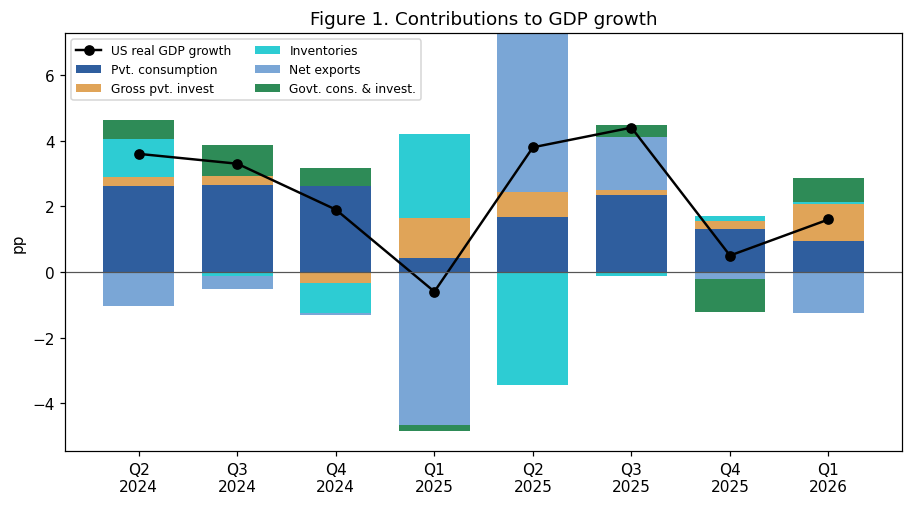

In [4]:
# Figure 1. Contributions to GDP growth (stacked bars) + US real GDP growth (line)
W = pct.index[-8:]
f1 = cg.loc[W, ["DPCERY", "A007RY", "A014RY", "A019RY", "A822RY"]].copy()
f1.columns = ["Pvt. consumption", "Gross pvt. invest", "Inventories", "Net exports", "Govt. cons. & invest."]
COL1 = {"Pvt. consumption": "#2f5e9e", "Gross pvt. invest": "#e0a458", "Inventories": "#2dccd3",
        "Net exports": "#7aa6d6", "Govt. cons. & invest.": "#2e8b57"}
x = np.arange(len(W))
fig, ax = plt.subplots(figsize=(8.4, 4.7))
stacked_bars(ax, x, f1, COL1)
ax.plot(x, pct.loc[W, "A191RL"].to_numpy(), "o-", color="black", lw=1.6, label="US real GDP growth")
ax.axhline(0, color="#555", lw=0.8)
qticks(ax, W)
ax.set_ylabel("pp"); ax.set_title("Figure 1. Contributions to GDP growth")
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(OUTDIR / "q1gdp_fig1_gdp_contributions.png", bbox_inches="tight"); plt.show()

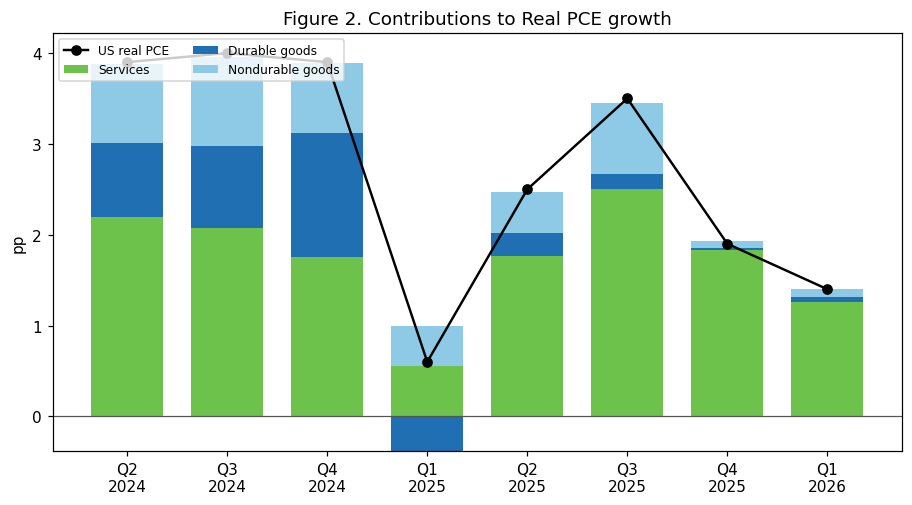

In [5]:
# Figure 2. Contributions to real PCE growth (stacked bars) + US real PCE (line)
W = cp.index[-8:]
f2 = cp.loc[W, ["DSERRZ", "DDURRZ", "DNDGRZ"]].copy()
f2.columns = ["Services", "Durable goods", "Nondurable goods"]
COL2 = {"Services": "#6cc24a", "Durable goods": "#1f6fb2", "Nondurable goods": "#8ecae6"}
x = np.arange(len(W))
fig, ax = plt.subplots(figsize=(8.4, 4.7))
stacked_bars(ax, x, f2, COL2)
ax.plot(x, cp.loc[W, "DPCERL"].to_numpy(), "o-", color="black", lw=1.6, label="US real PCE")
ax.axhline(0, color="#555", lw=0.8)
qticks(ax, W)
ax.set_ylabel("pp"); ax.set_title("Figure 2. Contributions to Real PCE growth")
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(OUTDIR / "q1gdp_fig2_pce_contributions.png", bbox_inches="tight"); plt.show()

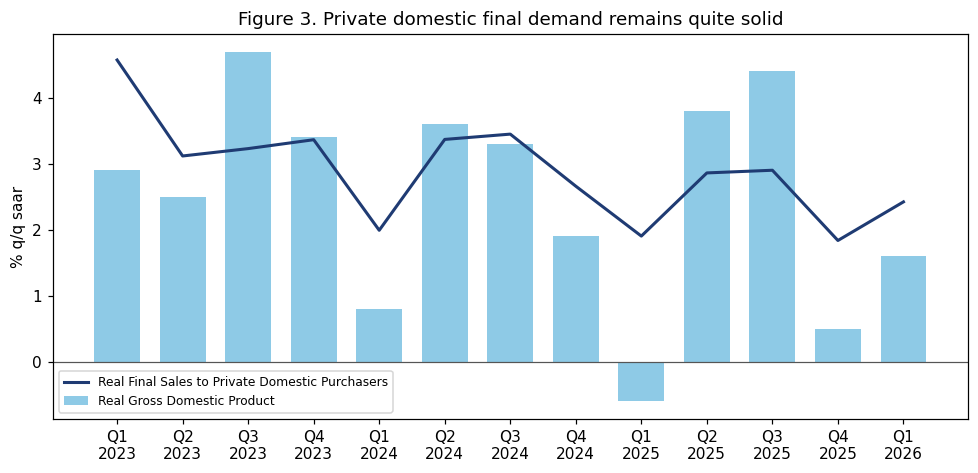

In [6]:
# Figure 3. Real GDP (bars) vs Real final sales to private domestic purchasers / PDFP (line)
W = pct.index[pct.index >= "2023-01-01"]
x = np.arange(len(W))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x, pct.loc[W, "A191RL"].to_numpy(), color="#8ecae6", width=0.7, label="Real Gross Domestic Product")
ax.plot(x, pdfp_saar.loc[W].to_numpy(), color="#1f3b73", lw=2.0,
        label="Real Final Sales to Private Domestic Purchasers")
ax.axhline(0, color="#555", lw=0.8)
qticks(ax, W)
ax.set_ylabel("% q/q saar"); ax.set_title("Figure 3. Private domestic final demand remains quite solid")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout(); fig.savefig(OUTDIR / "q1gdp_fig3_gdp_vs_pdfp.png", bbox_inches="tight"); plt.show()

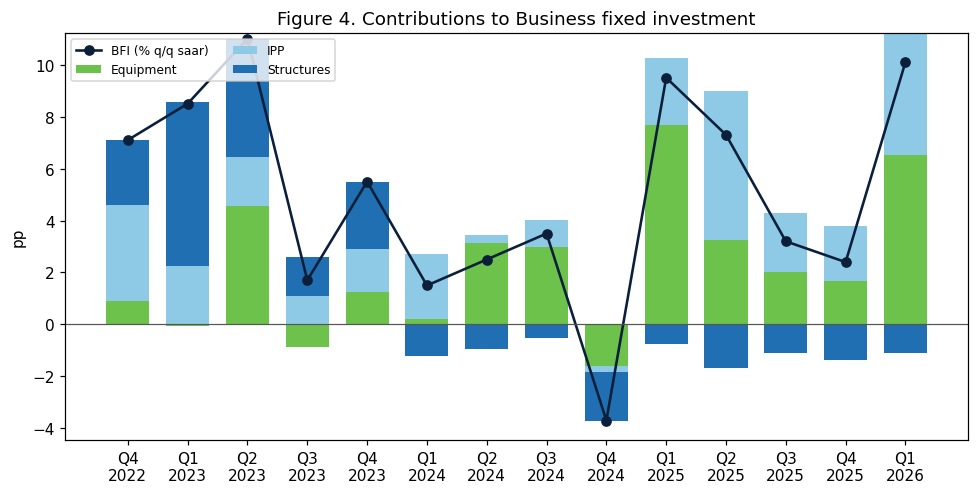

In [7]:
# Figure 4. Contributions to business fixed investment (stacked) + BFI (line)
W = bfi_contrib.index[bfi_contrib.index >= "2022-10-01"]
f4 = bfi_contrib.loc[W, ["Y033RY", "Y001RY", "A009RY"]].copy()
f4.columns = ["Equipment", "IPP", "Structures"]
COL4 = {"Equipment": "#6cc24a", "IPP": "#8ecae6", "Structures": "#1f6fb2"}
x = np.arange(len(W))
fig, ax = plt.subplots(figsize=(9, 4.6))
stacked_bars(ax, x, f4, COL4)
ax.plot(x, nonres_g.loc[W].to_numpy(), "o-", color="#0b1f3a", lw=1.7, label="BFI (% q/q saar)")
ax.axhline(0, color="#555", lw=0.8)
qticks(ax, W)
ax.set_ylabel("pp"); ax.set_title("Figure 4. Contributions to Business fixed investment")
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(OUTDIR / "q1gdp_fig4_bfi_contributions.png", bbox_inches="tight"); plt.show()

In [8]:
# Figure 5. Summary table — latest BEA vintage (% q/q saar and contribution to GDP, pp)
q = last_q
rows = [
    ("Real GDP",                       pct.loc[q, "A191RL"], np.nan,              True),
    ("Final sales to dom. purchasers", fsdp_saar.loc[q],     np.nan,              False),
    ("Private consumption",            pct.loc[q, "DPCERL"], cg.loc[q, "DPCERY"], False),
    ("Public consump. and invest.",    pct.loc[q, "A822RL"], cg.loc[q, "A822RY"], False),
    ("Residential investment",         pct.loc[q, "A011RL"], cg.loc[q, "A011RY"], False),
    ("Equipment investment",           pct.loc[q, "Y033RL"], cg.loc[q, "Y033RY"], False),
    ("IP investment",                  pct.loc[q, "Y001RL"], cg.loc[q, "Y001RY"], False),
    ("Structures investment",          pct.loc[q, "A009RL"], cg.loc[q, "A009RY"], False),
    ("Net exports",                    np.nan,               cg.loc[q, "A019RY"], False),
    ("Change in private invent.",      np.nan,               cg.loc[q, "A014RY"], False),
    ("Private dom. final purchasers",  pdfp_saar.loc[q],     np.nan,              True),
]
fig5 = pd.DataFrame(rows, columns=["Category", "% q/q (saar)", "Contribution (pp)", "_bold"])

def _fmt(v):  return "–" if pd.isna(v) else f"{v:+.1f}"
def _color(s):
    return ["color:#aaa;" if pd.isna(v) else
            ("color:#0a7d2c;" if v > 0 else ("color:#c0392b;" if v < 0 else "color:#888;")) for v in s]

_bold = fig5["_bold"].tolist()
NUMC  = ["% q/q (saar)", "Contribution (pp)"]
styled = (fig5[["Category"] + NUMC].style
    .format({c: _fmt for c in NUMC})
    .apply(lambda r: [f"font-weight:{'700' if _bold[r.name] else '400'};"] * len(r), axis=1)
    .apply(_color, subset=NUMC)
    .hide(axis="index")
    .set_caption(f"Figure 5. US Real GDP — Q{(q.month-1)//3+1} {q.year} (latest BEA vintage, second estimate not distinguished)")
    .set_properties(subset=["Category"], **{"text-align": "left"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "700"), ("font-size", "13px"),
                                          ("padding", "6px"), ("caption-side", "top")]},
        {"selector": "th.col_heading", "props": [("text-align", "right")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "2px 12px")]}]))
display(styled)

Category,% q/q (saar),Contribution (pp)
Real GDP,+1.6,–
Final sales to dom. purchasers,+2.7,–
Private consumption,+1.4,+0.9
Public consump. and invest.,+4.4,+0.7
Residential investment,-6.2,-0.2
Equipment investment,+17.2,+0.9
IP investment,+11.6,+0.6
Structures investment,-5.4,-0.1
Net exports,–,-1.2
Change in private invent.,–,+0.1


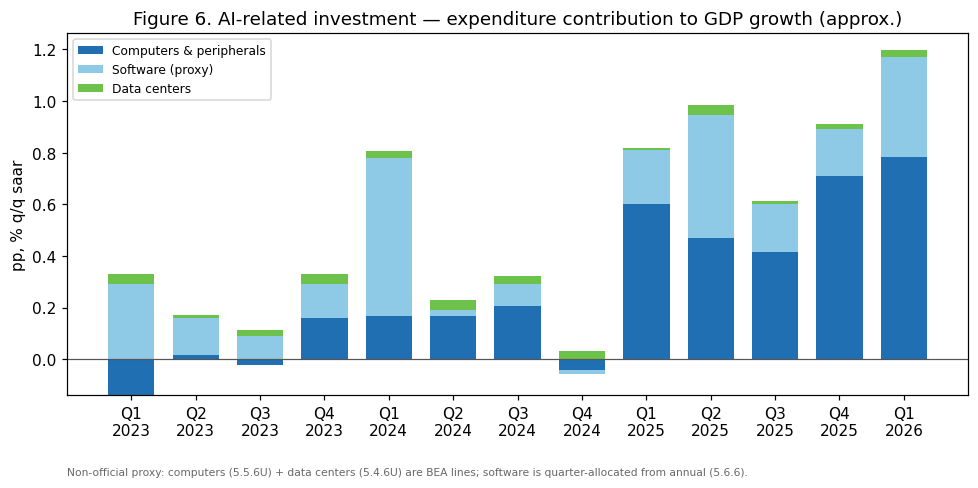

In [9]:
# Figure 6. AI-related investment — expenditure contribution to GDP growth (NON-OFFICIAL proxy)
W = ai_contrib.index[ai_contrib.index >= "2023-01-01"]
f6 = ai_contrib.loc[W, ["Computers & peripherals", "Software (proxy)", "Data centers"]]
COL6 = {"Computers & peripherals": "#1f6fb2", "Software (proxy)": "#8ecae6", "Data centers": "#6cc24a"}
x = np.arange(len(W))
fig, ax = plt.subplots(figsize=(9, 4.6))
stacked_bars(ax, x, f6, COL6)
ax.axhline(0, color="#555", lw=0.8)
qticks(ax, W)
ax.set_ylabel("pp, % q/q saar")
ax.set_title("Figure 6. AI-related investment — expenditure contribution to GDP growth (approx.)")
ax.legend(loc="upper left", fontsize=8)
ax.text(0.0, -0.22, "Non-official proxy: computers (5.5.6U) + data centers (5.4.6U) are BEA lines; "
        "software is quarter-allocated from annual (5.6.6).", transform=ax.transAxes, fontsize=7,
        color="#666")
fig.tight_layout(); fig.savefig(OUTDIR / "q1gdp_fig6_ai_investment.png", bbox_inches="tight"); plt.show()

### Figure 6b — nominal-weighted variant (BEA Table 5.5.6U footnote fix)

The Table 5.5.6U footnote warns that chained-dollar **levels** of computers should not be used to
gauge a component's relative importance or its contribution to an aggregate, because computers'
relative prices move sharply. **Figure 6 (above)** weights each component by its chained-dollar level
change. **Figure 6b (below)** instead weights each component by its **current-dollar (nominal) share
of GDP** and multiplies by its **real** growth rate — which is exactly how BEA constructs its official
*contributions to percent change in real GDP*.

**This is still a contribution to *real* GDP growth, not nominal GDP** — only the weight changes
(current-dollar share), not the growth measure (still real). In the 2023–2026 window the two methods
agree within ~0.01pp because computer prices have been roughly flat since 2017; the nominal weighting
mainly future-proofs the chart for longer windows and fixes the relative importance of computers vs
data centers (whose structures prices have *risen*, so chained understates them).

Contribution to REAL GDP, 2026-01-01 (pp):
                         chained-diff (Fig 6)  nominal-weighted (Fig 6b)
Computers & peripherals                 0.783                      0.781
Software (proxy)                        0.388                      0.285
Data centers                            0.025                      0.033
TOTAL                                   1.196                      1.099


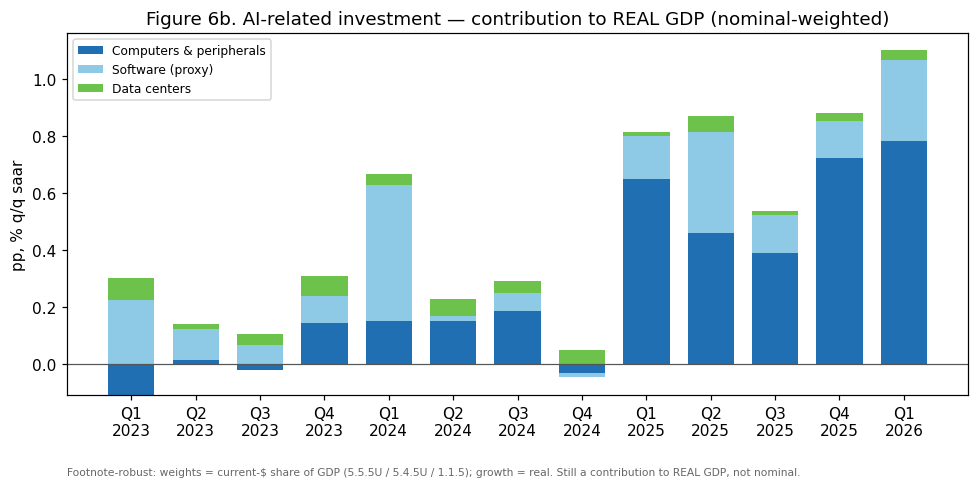

In [10]:
# Figure 6b. AI-related investment, contribution to REAL GDP growth -- NOMINAL-WEIGHTED (footnote-robust)
# CHANGE vs Figure 6: each component is weighted by its CURRENT-DOLLAR (nominal) share of GDP and
# multiplied by its REAL growth rate (BEA's official method for contributions to real GDP). Figure 6
# instead used chained-dollar level changes -- the operation the 5.5.6U footnote cautions against.
# Result is STILL a contribution to REAL GDP, not nominal GDP; only the weighting differs.
nomgdp   = fetch_bea("T10105")                                          # current-$ GDP table (A191RC, Y001RC)
comp_rc  = fetch_bea("U50505", dataset="NIUnderlyingDetail")["B935RC"]  # computers, current $
dc_rc    = fetch_bea("U50405", dataset="NIUnderlyingDetail")["LA001282"]# data centers, current $
ipp_rc_a = fetch_bea("T50605", freq="A")                               # IPP by type, current $, ANNUAL

# quarterly nominal software proxy (same annual-share allocation as the chained proxy in Fig 6)
sws = ipp_rc_a["B985RC"] / ipp_rc_a["Y001RC"]; sws.index = sws.index.year
sws = sws.reindex(yrs).ffill().bfill()
software_rc = nomgdp["Y001RC"] * pd.Series(nomgdp.index.year, index=nomgdp.index).map(sws)

nom_lvl = pd.DataFrame({                                                # nominal levels on the quarterly grid
    "Computers & peripherals": comp_rc,
    "Software (proxy)":        software_rc,
    "Data centers":            dc_rc,
}).reindex(lev.index)

real_g = (ai / ai.shift(1)) ** 4 - 1                                    # real growth saar (ai = chained levels, Fig 6)
gdp_rc = nomgdp["A191RC"]
ai_contrib_nom = nom_lvl.shift(1).div(gdp_rc.shift(1), axis=0).mul(real_g) * 100  # contribution to REAL GDP (pp)

cmp = pd.DataFrame({"chained-diff (Fig 6)":      ai_contrib.loc[last_q],
                    "nominal-weighted (Fig 6b)": ai_contrib_nom.loc[last_q]})
cmp.loc["TOTAL"] = cmp.sum()
print(f"Contribution to REAL GDP, {last_q.date()} (pp):")
print(cmp.round(3))

W = ai_contrib_nom.index[ai_contrib_nom.index >= "2023-01-01"]
f6b = ai_contrib_nom.loc[W, ["Computers & peripherals", "Software (proxy)", "Data centers"]]
COL6 = {"Computers & peripherals": "#1f6fb2", "Software (proxy)": "#8ecae6", "Data centers": "#6cc24a"}
x = np.arange(len(W))
fig, ax = plt.subplots(figsize=(9, 4.6))
stacked_bars(ax, x, f6b, COL6)
ax.axhline(0, color="#555", lw=0.8)
qticks(ax, W)
ax.set_ylabel("pp, % q/q saar")
ax.set_title("Figure 6b. AI-related investment — contribution to REAL GDP (nominal-weighted)")
ax.legend(loc="upper left", fontsize=8)
ax.text(0.0, -0.22, "Footnote-robust: weights = current-$ share of GDP (5.5.5U / 5.4.5U / 1.1.5); "
        "growth = real. Still a contribution to REAL GDP, not nominal.", transform=ax.transAxes,
        fontsize=7, color="#666")
fig.tight_layout()
fig.savefig(OUTDIR / "q1gdp_fig6b_ai_investment_nominal_weighted.png", bbox_inches="tight"); plt.show()

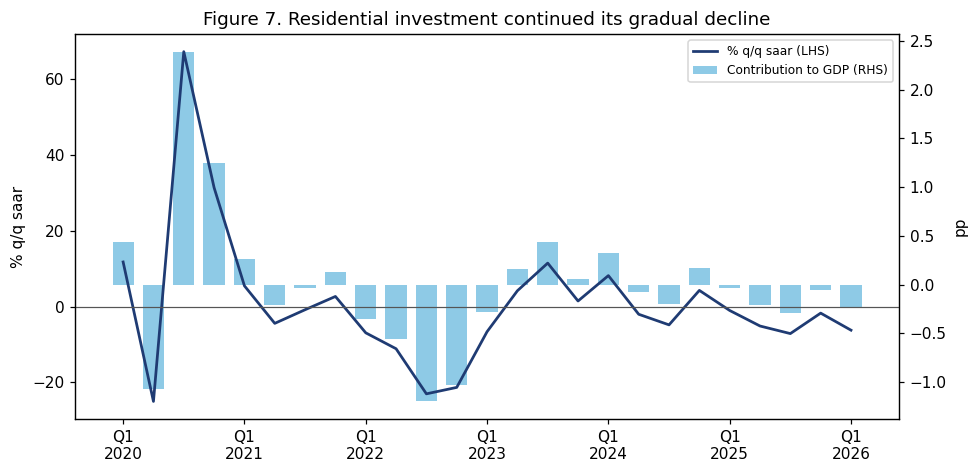

In [11]:
# Figure 7. Residential investment: % q/q saar (line, LHS) + contribution to GDP (bars, RHS)
W = pct.index[pct.index >= "2020-01-01"]
x = np.arange(len(W))
fig, ax1 = plt.subplots(figsize=(9, 4.4))
ax2 = ax1.twinx()
ax2.bar(x, cg.loc[W, "A011RY"].to_numpy(), color="#8ecae6", width=0.7, label="Contribution to GDP (RHS)")
ax1.plot(x, pct.loc[W, "A011RL"].to_numpy(), color="#1f3b73", lw=1.8, label="% q/q saar (LHS)")
ax1.set_zorder(ax2.get_zorder() + 1); ax1.patch.set_visible(False)   # line drawn above bars
ax1.axhline(0, color="#555", lw=0.8)
qticks(ax1, W, every=4)
ax1.set_ylabel("% q/q saar"); ax2.set_ylabel("pp")
ax1.set_title("Figure 7. Residential investment continued its gradual decline")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
fig.tight_layout(); fig.savefig(OUTDIR / "q1gdp_fig7_residential.png", bbox_inches="tight"); plt.show()

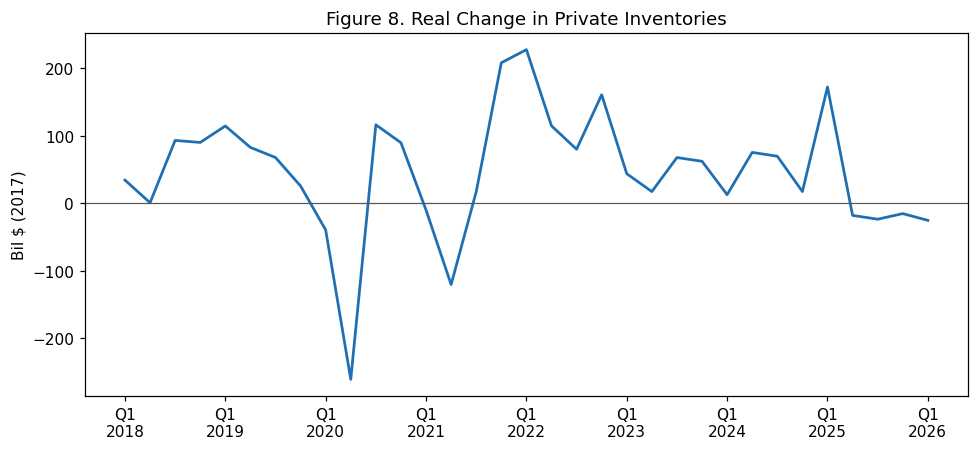

In [12]:
# Figure 8. Real change in private inventories (billions of chained 2017 $)
W = lev.index[lev.index >= "2018-01-01"]
x = np.arange(len(W))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(x, (lev.loc[W, "A014RX"] / 1000).to_numpy(), color="#1f6fb2", lw=1.8)  # millions -> billions
ax.axhline(0, color="#555", lw=0.8)
qticks(ax, W, every=4)
ax.set_ylabel("Bil $ (2017)"); ax.set_title("Figure 8. Real Change in Private Inventories")
fig.tight_layout(); fig.savefig(OUTDIR / "q1gdp_fig8_inventory_change.png", bbox_inches="tight"); plt.show()

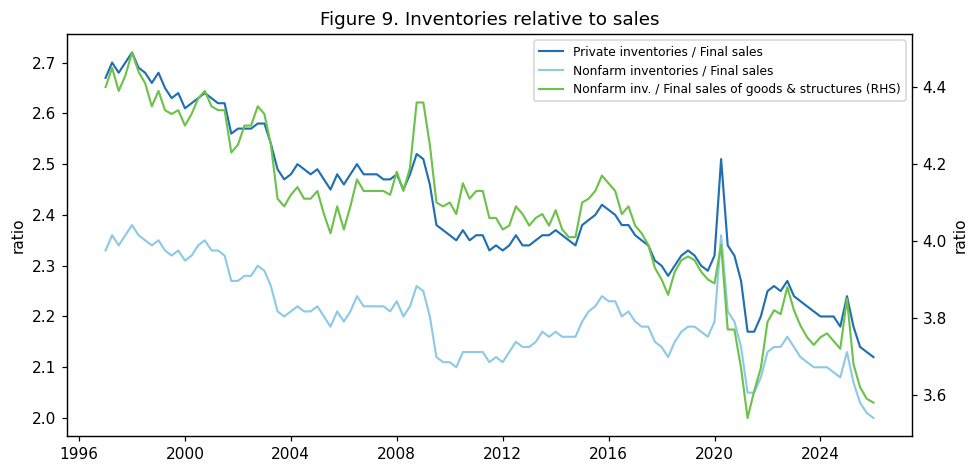

In [13]:
# Figure 9. Inventories relative to sales (chained-dollar ratios)
W = rat.index[rat.index >= "1997-01-01"]
fig, ax1 = plt.subplots(figsize=(9, 4.4))
ax1.plot(W, rat.loc[W, "A811RX"], color="#1f6fb2", lw=1.4, label="Private inventories / Final sales")
ax1.plot(W, rat.loc[W, "A812RX"], color="#8ecae6", lw=1.4, label="Nonfarm inventories / Final sales")
ax2 = ax1.twinx()
ax2.plot(W, rat.loc[W, "A813RX"], color="#6cc24a", lw=1.4,
         label="Nonfarm inv. / Final sales of goods & structures (RHS)")
ax1.set_ylabel("ratio"); ax2.set_ylabel("ratio")
ax1.set_title("Figure 9. Inventories relative to sales")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
fig.tight_layout(); fig.savefig(OUTDIR / "q1gdp_fig9_inventory_sales.png", bbox_inches="tight"); plt.show()

In [14]:
# Export headline series (tidy long format) + the Figure 5 table
keep = pd.DataFrame({
    "GDP_pct_saar": pct["A191RL"], "PCE_pct_saar": cp["DPCERL"], "PDFP_pct_saar": pdfp_saar,
    "BFI_pct_saar": nonres_g, "Residential_pct_saar": pct["A011RL"],
    "GDP_contrib_PCE": cg["DPCERY"], "GDP_contrib_fixed_inv": cg["A007RY"],
    "GDP_contrib_inventories": cg["A014RY"], "GDP_contrib_net_exports": cg["A019RY"],
    "GDP_contrib_govt": cg["A822RY"],
    "ChangePrivInv_chained2017bil": lev["A014RX"],
    "InvSales_private": rat["A811RX"], "InvSales_nonfarm": rat["A812RX"],
    "InvSales_nonfarm_goods_struct": rat["A813RX"],
})
keep.index.name = "date"
(keep.reset_index().melt("date", var_name="series", value_name="value").dropna()
     .to_csv(OUTDIR / "q1gdp_data.csv", index=False))
fig5.drop(columns="_bold").to_csv(OUTDIR / "q1gdp_fig5_table.csv", index=False)

print("Wrote:")
for p in sorted(OUTDIR.glob("q1gdp_*")):
    print("  ", p)

Wrote:
   outputs\q1gdp_data.csv
   outputs\q1gdp_fig1_gdp_contributions.png
   outputs\q1gdp_fig2_pce_contributions.png
   outputs\q1gdp_fig3_gdp_vs_pdfp.png
   outputs\q1gdp_fig4_bfi_contributions.png
   outputs\q1gdp_fig5_table.csv
   outputs\q1gdp_fig6_ai_investment.png
   outputs\q1gdp_fig6b_ai_investment_nominal_weighted.png
   outputs\q1gdp_fig7_residential.png
   outputs\q1gdp_fig8_inventory_change.png
   outputs\q1gdp_fig9_inventory_sales.png
